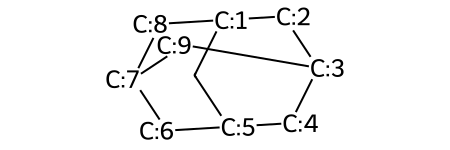

In [1]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw

def mol_with_atom_index(mol):
    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(atom.GetIdx())
    return mol

mol = Chem.MolFromSmiles("C1C2CC3CC1CC(C2)C3")
mol_with_atom_index(mol)

In [21]:
def bridged_bicycles(smi):
    """ Checking the criteria based on graph
    """
    mol = Chem.MolFromSmiles(smi)
    ring_info = mol.GetRingInfo()
    atom_rings = ring_info.AtomRings()

    num_paths = 0
    for i in range(len(atom_rings)):
        for j in range(i+1, len(atom_rings)):
            shared = set(atom_rings[i]).intersection(atom_rings[j])
            if len(shared) > 1:
                for path in Chem.rdmolops.FindAllPathsOfLengthN(mol, 3, useBonds=False):
                    if set(path) == set(shared):
                        num_paths += 1
                if num_paths >= 1:
                    return True
    return False

bridged_bicycles("C1C2CC3CC1CC(C2)C3")ls


True